# Desafío: Regresión Lineal Múltiple vs. Regresión Logística

**Minería de Datos — Unidad 2/3**

Este notebook contiene dos desafíos:

1. **Desafío 1** — Ajustar y evaluar una regresión lineal múltiple con dos variables predictoras (3 dimensiones en total), midiendo su R² y visualizando el plano ajustado.
2. **Desafío 2** — Intentar el mismo procedimiento sobre datos que en realidad corresponden a un problema de clasificación binaria, para evidenciar por qué la regresión lineal es inadecuada en ese caso.

Completa las celdas marcadas con `# TODO`. La sección final contiene la solución, por si necesitas verificar tu trabajo.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (requerido para proyección 3D)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)

## 🎯 Desafío 1: Regresión Lineal Múltiple (2 variables → 3D)

**Escenario:** una inmobiliaria quiere predecir el **precio de arriendo** (UF) de un departamento a partir de:

- `metros_cuadrados` (X₁)
- `antiguedad` en años (X₂)

Con dos variables predictoras y una variable de respuesta, el problema tiene exactamente 3 dimensiones y puede visualizarse por completo.

**Tu tarea:**
1. Ajustar un modelo `LinearRegression` con ambas variables predictoras.
2. Calcular el R² del modelo.
3. Graficar en 3D los datos observados junto con el plano de regresión ajustado.
4. Responder las preguntas de cierre.

In [4]:
# Datos provistos — no es necesario modificar esta celda
n = 150
metros_cuadrados = np.random.uniform(30, 120, n)
antiguedad = np.random.uniform(0, 40, n)
ruido = np.random.normal(0, 3, n)

precio_arriendo = 5 + 0.35 * metros_cuadrados - 0.15 * antiguedad + ruido

df1 = pd.DataFrame({
    "metros_cuadrados": metros_cuadrados,
    "antiguedad": antiguedad,
    "precio_arriendo": precio_arriendo,
})
df1.head()

,metros_cuadrados,antiguedad,precio_arriendo
0,63.708611,36.330635,21.985134
1,115.564288,9.582476,42.055328
2,95.879455,5.795795,44.120272
3,83.879264,19.578110,33.322783
4,44.041678,39.426018,8.425257


In [ ]:
# TODO 1: Arma la matriz de variables independientes X (metros_cuadrados y antiguedad)
# y el vector objetivo y (precio_arriendo).
X = ...  # <- completar, shape (n, 2)
y = ...  # <- completar, shape (n,)

# TODO 2: Crea y entrena un modelo LinearRegression con X e y.
modelo = ...  # <- completar

# TODO 3: Genera las predicciones del modelo sobre X.
y_pred = ...  # <- completar

# TODO 4: Calcula el R² comparando y con y_pred (usa r2_score o modelo.score).
r2 = ...  # <- completar

print(f"Coeficientes (w1, w2): {modelo.coef_}")
print(f"Intercepto (b): {modelo.intercept_:.3f}")
print(f"R²: {r2:.3f}")

In [ ]:
# TODO 5: Completa el gráfico 3D: dispersión de los datos reales + plano de regresión ajustado.
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df1["metros_cuadrados"], df1["antiguedad"], df1["precio_arriendo"],
           color="#002038", s=35, label="Datos observados")

xx, yy = np.meshgrid(
    np.linspace(df1["metros_cuadrados"].min(), df1["metros_cuadrados"].max(), 15),
    np.linspace(df1["antiguedad"].min(), df1["antiguedad"].max(), 15),
)

# TODO: usa los coeficientes e intercepto del modelo para calcular el plano zz
zz = ...  # <- completar: zz = intercepto + coef[0]*xx + coef[1]*yy

ax.plot_surface(xx, yy, zz, alpha=0.4, color="#F8B31C")
ax.set_xlabel("Metros cuadrados")
ax.set_ylabel("Antigüedad (años)")
ax.set_zlabel("Precio de arriendo (UF)")
ax.set_title(f"Regresión lineal múltiple — R² = {r2:.3f}")
ax.legend()
plt.show()

**Preguntas de cierre — Desafío 1:**

- ¿Qué variable tiene mayor efecto sobre el precio de arriendo, según la magnitud de los coeficientes?
- ¿Qué significa un R² cercano a 1? ¿Y uno cercano a 0?
- ¿El signo del coeficiente de `antiguedad` es consistente con lo esperado?

## 🚫 Desafío 2: La Regresión Imposible

**Escenario:** un banco quiere predecir si un cliente **pagará su crédito** (Sí = 1 / No = 0) según su `ingreso` mensual. El equipo de datos, sin evaluar el tipo de variable de respuesta, decide aplicar el mismo procedimiento del Desafío 1: ajustar una `LinearRegression` directamente sobre la variable binaria.

**Tu tarea:**
1. Intenta ajustar una `LinearRegression` para predecir la variable binaria a partir del ingreso.
2. Calcula el R².
3. Grafica en 2D los puntos (ingreso vs. resultado binario) junto con la recta ajustada.
4. Observa qué ocurre con las predicciones fuera del rango de datos y concluye por qué este enfoque es inadecuado.

In [5]:
# Datos provistos — no es necesario modificar esta celda
n2 = 150
ingreso = np.random.uniform(0, 10, n2)  # ingreso mensual (escala ficticia, millones de pesos)
probabilidad = 1 / (1 + np.exp(-(ingreso - 5)))
pago_credito = np.random.binomial(1, probabilidad)  # 1 = paga, 0 = no paga

df2 = pd.DataFrame({"ingreso": ingreso, "pago_credito": pago_credito})
df2.head()

,ingreso,pago_credito
0,4.636984,0
1,3.533522,1
2,5.836561,1
3,0.777346,0
4,9.743948,1


In [ ]:
# TODO 1: Arma X2 (ingreso) e y2 (pago_credito, tratada como si fuera continua).
X2 = ...  # <- completar, recuerda que LinearRegression espera una matriz 2D: shape (n2, 1)
y2 = ...  # <- completar

# TODO 2: Ajusta un modelo LinearRegression con X2 e y2.
modelo2 = ...  # <- completar

# TODO 3: Genera predicciones sobre X2 y calcula el R².
y2_pred = ...  # <- completar
r2_2 = ...  # <- completar

print(f"R²: {r2_2:.3f}")
print(f"Predicción del modelo para ingreso = 0:  {modelo2.predict([[0]])[0]:.3f}")
print(f"Predicción del modelo para ingreso = 10: {modelo2.predict([[10]])[0]:.3f}")

In [ ]:
# TODO 4: Completa el gráfico de dispersión 2D (ingreso vs. pago_credito) + la recta ajustada.
plt.figure(figsize=(8, 6))
plt.scatter(df2["ingreso"], df2["pago_credito"], color="#002038", alpha=0.6,
            label="Datos observados (0/1)")

x_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = ...  # <- completar: usa modelo2 para predecir sobre x_line

plt.plot(x_line, y_line, color="#E24B4A", linewidth=2, label="Recta ajustada")
plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.axhline(1, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Ingreso mensual")
plt.ylabel("Pago del crédito (0 = No, 1 = Sí)")
plt.title(f"¿Por qué falla la regresión lineal aquí? — R² = {r2_2:.3f}")
plt.legend()
plt.show()

**Preguntas de cierre — Desafío 2:**

- Observando el gráfico: ¿qué forma tiene la distribución de los puntos (0 y 1) a lo largo del eje `ingreso`?
- ¿Qué valores toma la recta ajustada para ingresos muy bajos o muy altos? ¿Tienen sentido como probabilidad?
- ¿Por qué el R² obtenido no es una medida confiable de qué tan bien el modelo predice el resultado?
- ¿Qué modelo, visto en clases, sí está diseñado para este tipo de variable de respuesta binaria?

---
## ⚠️ Solución (uso docente)

Sección de referencia para corrección. Se recomienda remover estas celdas antes de distribuir el notebook a los estudiantes.

In [6]:
# --- Solución Desafío 1 ---
X = df1[["metros_cuadrados", "antiguedad"]].values
y = df1["precio_arriendo"].values

modelo = LinearRegression()
modelo.fit(X, y)

y_pred = modelo.predict(X)
r2 = r2_score(y, y_pred)

print(f"Coeficientes (w1, w2): {modelo.coef_}")
print(f"Intercepto (b): {modelo.intercept_:.3f}")
print(f"R²: {r2:.3f}")

Coeficientes (w1, w2): [ 0.35868458 -0.1676161 ]
Intercepto (b): 4.919
R²: 0.925


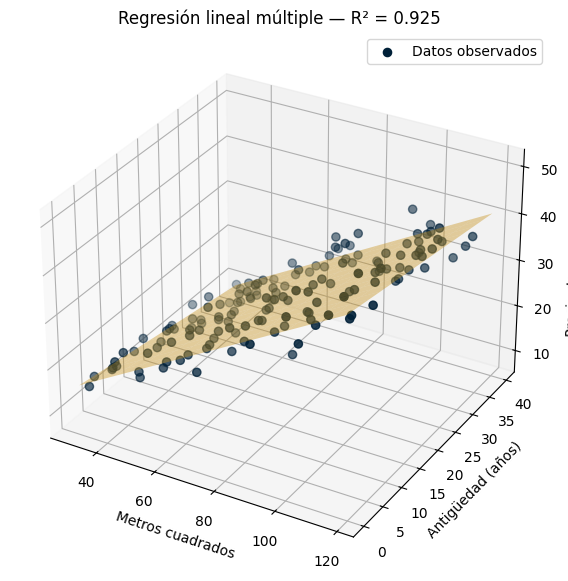

In [7]:
# --- Solución Desafío 1: gráfico 3D ---
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df1["metros_cuadrados"], df1["antiguedad"], df1["precio_arriendo"],
           color="#002038", s=35, label="Datos observados")

xx, yy = np.meshgrid(
    np.linspace(df1["metros_cuadrados"].min(), df1["metros_cuadrados"].max(), 15),
    np.linspace(df1["antiguedad"].min(), df1["antiguedad"].max(), 15),
)
zz = modelo.intercept_ + modelo.coef_[0] * xx + modelo.coef_[1] * yy

ax.plot_surface(xx, yy, zz, alpha=0.4, color="#F8B31C")
ax.set_xlabel("Metros cuadrados")
ax.set_ylabel("Antigüedad (años)")
ax.set_zlabel("Precio de arriendo (UF)")
ax.set_title(f"Regresión lineal múltiple — R² = {r2:.3f}")
ax.legend()
plt.show()

In [8]:
# --- Solución Desafío 2 ---
X2 = df2[["ingreso"]].values
y2 = df2["pago_credito"].values

modelo2 = LinearRegression()
modelo2.fit(X2, y2)

y2_pred = modelo2.predict(X2)
r2_2 = r2_score(y2, y2_pred)

print(f"R²: {r2_2:.3f}")
print(f"Predicción del modelo para ingreso = 0:  {modelo2.predict([[0]])[0]:.3f}")
print(f"Predicción del modelo para ingreso = 10: {modelo2.predict([[10]])[0]:.3f}")

R²: 0.638
Predicción del modelo para ingreso = 0:  -0.142
Predicción del modelo para ingreso = 10: 1.222


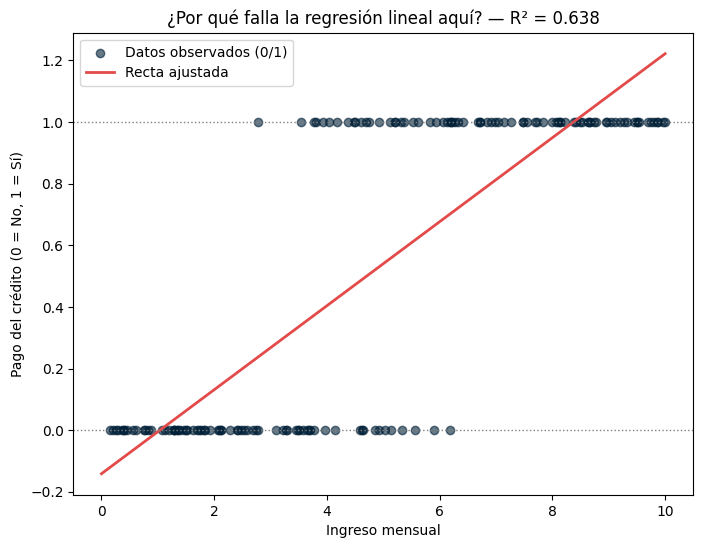

In [9]:
# --- Solución Desafío 2: gráfico 2D ---
plt.figure(figsize=(8, 6))
plt.scatter(df2["ingreso"], df2["pago_credito"], color="#002038", alpha=0.6,
            label="Datos observados (0/1)")

x_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = modelo2.predict(x_line)

plt.plot(x_line, y_line, color="#E24B4A", linewidth=2, label="Recta ajustada")
plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.axhline(1, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Ingreso mensual")
plt.ylabel("Pago del crédito (0 = No, 1 = Sí)")
plt.title(f"¿Por qué falla la regresión lineal aquí? — R² = {r2_2:.3f}")
plt.legend()
plt.show()

**Notas de corrección:**

- En el Desafío 2, el R² suele ser bajo o engañoso (puede ser positivo sin que el modelo tenga sentido predictivo), y la recta produce valores fuera de `[0, 1]` en los extremos del rango de `ingreso` — resultados sin interpretación como probabilidad.
- El gráfico 2D deja ver que los puntos se agrupan en dos bandas horizontales (0 y 1) con una transición en forma de S, patrón que una recta no puede capturar pero que sí modela una curva sigmoidea.
- Este resultado conecta directamente con el contenido de regresión logística: la variable de respuesta binaria requiere un modelo que acote las predicciones entre 0 y 1.